In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/6234.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/1269.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/3863.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/6241.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/623.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/2193.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/3750.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/2008.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/5982.jpg
/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/gray/2081.jpg
/kaggle/inp

In [4]:
import os

DATASET = "/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images"

print(os.listdir(DATASET))

['gray', 'color']


In [ ]:
import tensorflow as tf
import os

IMG_SIZE = 128

gray_dir = os.path.join(DATASET,"gray")
color_dir = os.path.join(DATASET,"color")

gray_images = sorted(os.listdir(gray_dir))
color_images = sorted(os.listdir(color_dir))

# Sanity check: make sure gray/color pairs actually match
assert len(gray_images) == len(color_images), "Mismatch in number of gray/color images"
assert gray_images == color_images, "Gray and color filenames don't align - pairs would be wrong"
print(f"Total pairs: {len(gray_images)}")

In [9]:
def load_image(gray_path,color_path):

    gray = tf.io.read_file(gray_path)
    gray = tf.image.decode_jpeg(gray,channels=1)

    color = tf.io.read_file(color_path)
    color = tf.image.decode_jpeg(color,channels=3)

    gray = tf.image.resize(gray,(IMG_SIZE,IMG_SIZE))
    color = tf.image.resize(color,(IMG_SIZE,IMG_SIZE))

    gray = tf.cast(gray,tf.float32)/255.0
    color = tf.cast(color,tf.float32)/255.0

    return gray,color

In [ ]:
gray_paths = [os.path.join(gray_dir,x) for x in gray_images]
color_paths = [os.path.join(color_dir,x) for x in color_images]

dataset = tf.data.Dataset.from_tensor_slices((gray_paths,color_paths))

dataset = dataset.map(load_image,
                      num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.shuffle(1000, seed=42)  # seed added so the split is reproducible

train_size = int(0.8*len(gray_paths))

train_ds = dataset.take(train_size).batch(16).prefetch(tf.data.AUTOTUNE)

val_ds = dataset.skip(train_size).batch(16).prefetch(tf.data.AUTOTUNE)

In [11]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [12]:
def conv_block(x,filters):

    x = Conv2D(filters,3,padding='same',activation='relu')(x)
    x = Conv2D(filters,3,padding='same',activation='relu')(x)

    p = MaxPooling2D()(x)

    return x,p

In [13]:
def up_block(x,skip,filters):

    x = UpSampling2D()(x)

    x = Concatenate()([x,skip])

    x = Conv2D(filters,3,padding='same',activation='relu')(x)
    x = Conv2D(filters,3,padding='same',activation='relu')(x)

    return x

In [14]:
inputs = Input((128,128,1))

c1,p1 = conv_block(inputs,64)
c2,p2 = conv_block(p1,128)
c3,p3 = conv_block(p2,256)
c4,p4 = conv_block(p3,512)

b = Conv2D(1024,3,padding='same',activation='relu')(p4)
b = Conv2D(1024,3,padding='same',activation='relu')(b)

u1 = up_block(b,c4,512)
u2 = up_block(u1,c3,256)
u3 = up_block(u2,c2,128)
u4 = up_block(u3,c1,64)

outputs = Conv2D(3,1,activation='sigmoid')(u4)

model = Model(inputs,outputs)

In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

In [21]:
import matplotlib.pyplot as plt

def show_predictions(model, dataset, num_samples=4):

    gray_batch, color_batch = next(iter(dataset))

    pred_batch = model.predict(gray_batch)

    plt.figure(figsize=(12,4*num_samples))

    for i in range(num_samples):

        # Input
        plt.subplot(num_samples,3,3*i+1)
        plt.imshow(gray_batch[i].numpy().squeeze(), cmap="gray")
        plt.title(f"Sample {i+1}: Input (Gray)")
        plt.axis("off")

        # Prediction
        plt.subplot(num_samples,3,3*i+2)
        plt.imshow(pred_batch[i])
        plt.title(f"Sample {i+1}: Prediction")
        plt.axis("off")

        # Target
        plt.subplot(num_samples,3,3*i+3)
        plt.imshow(color_batch[i])
        plt.title(f"Sample {i+1}: Target (Color)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


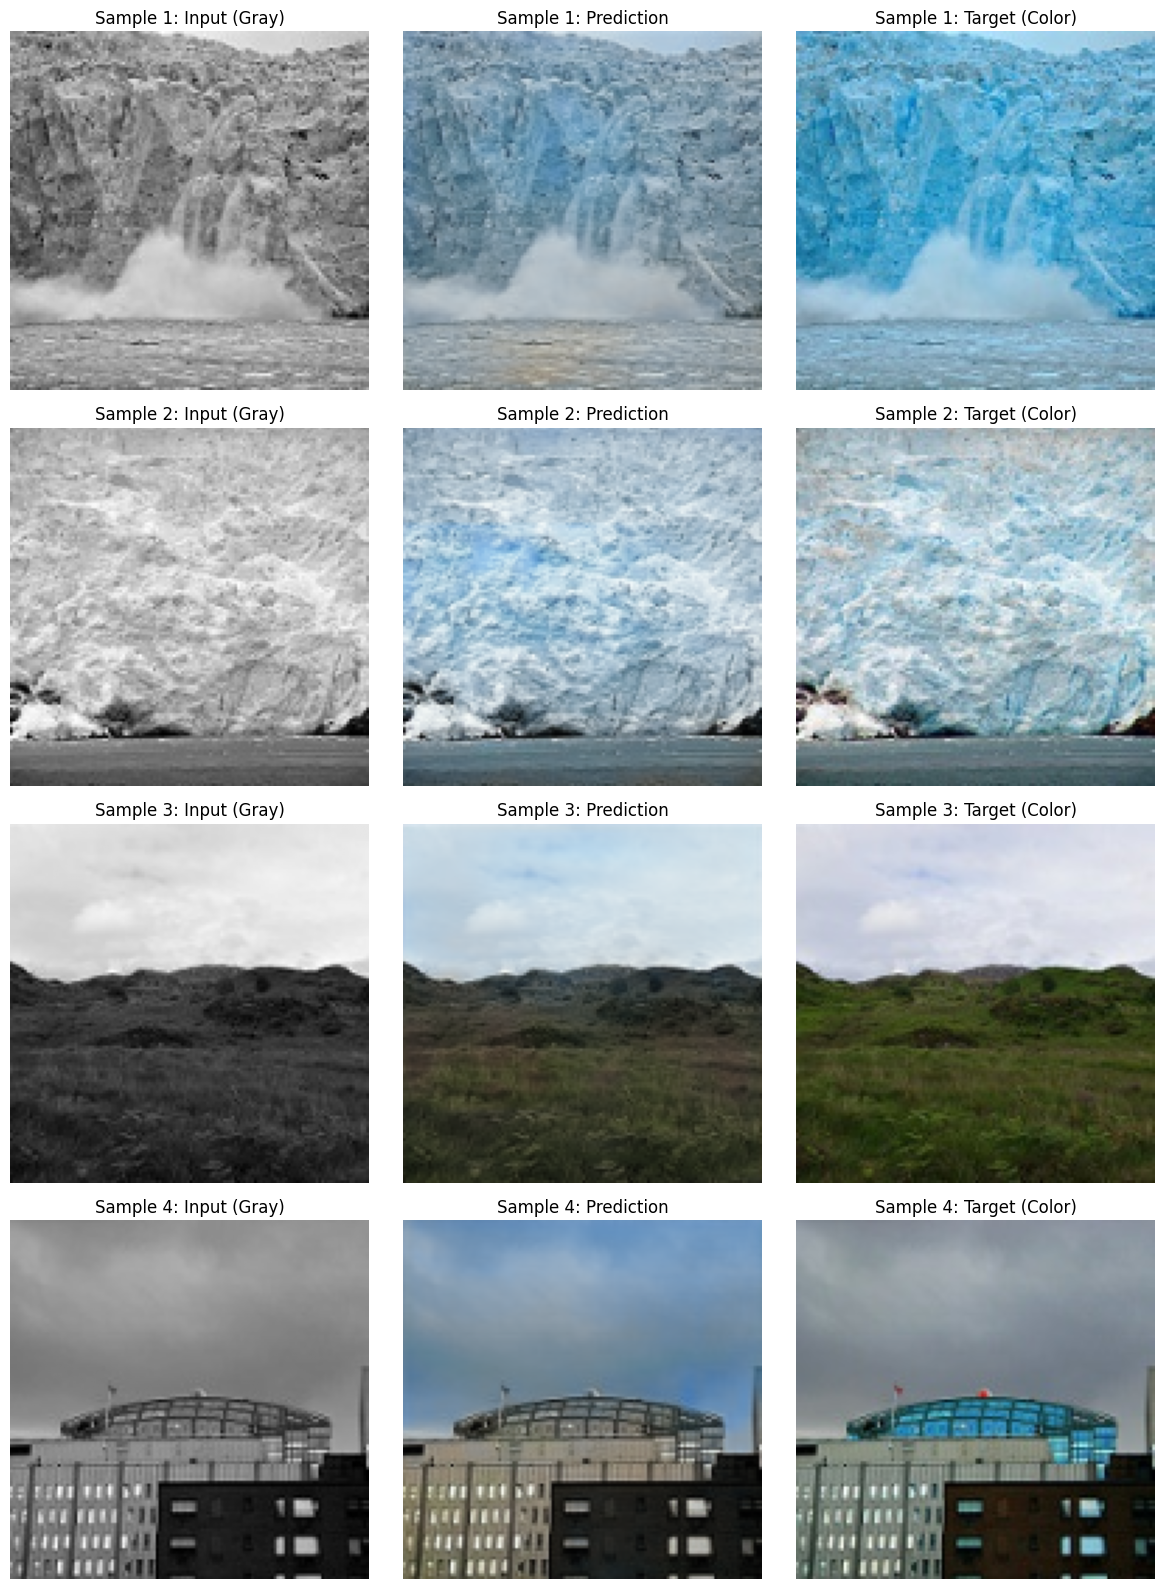

In [22]:
show_predictions(model, val_ds, num_samples=4)

In [23]:
import matplotlib.pyplot as plt

def visualize_results(model, dataset, num_samples=4):

    gray_imgs, color_imgs = next(iter(dataset))

    predictions = model.predict(gray_imgs, verbose=0)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    for i in range(num_samples):

        # Input Gray
        axes[i,0].imshow(gray_imgs[i].numpy().squeeze(), cmap='gray')
        axes[i,0].set_title(f"Sample {i+1}: Input (Gray)")
        axes[i,0].axis("off")

        # Prediction
        axes[i,1].imshow(predictions[i])
        axes[i,1].set_title(f"Sample {i+1}: Prediction")
        axes[i,1].axis("off")

        # Ground Truth
        axes[i,2].imshow(color_imgs[i])
        axes[i,2].set_title(f"Sample {i+1}: Target (Color)")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

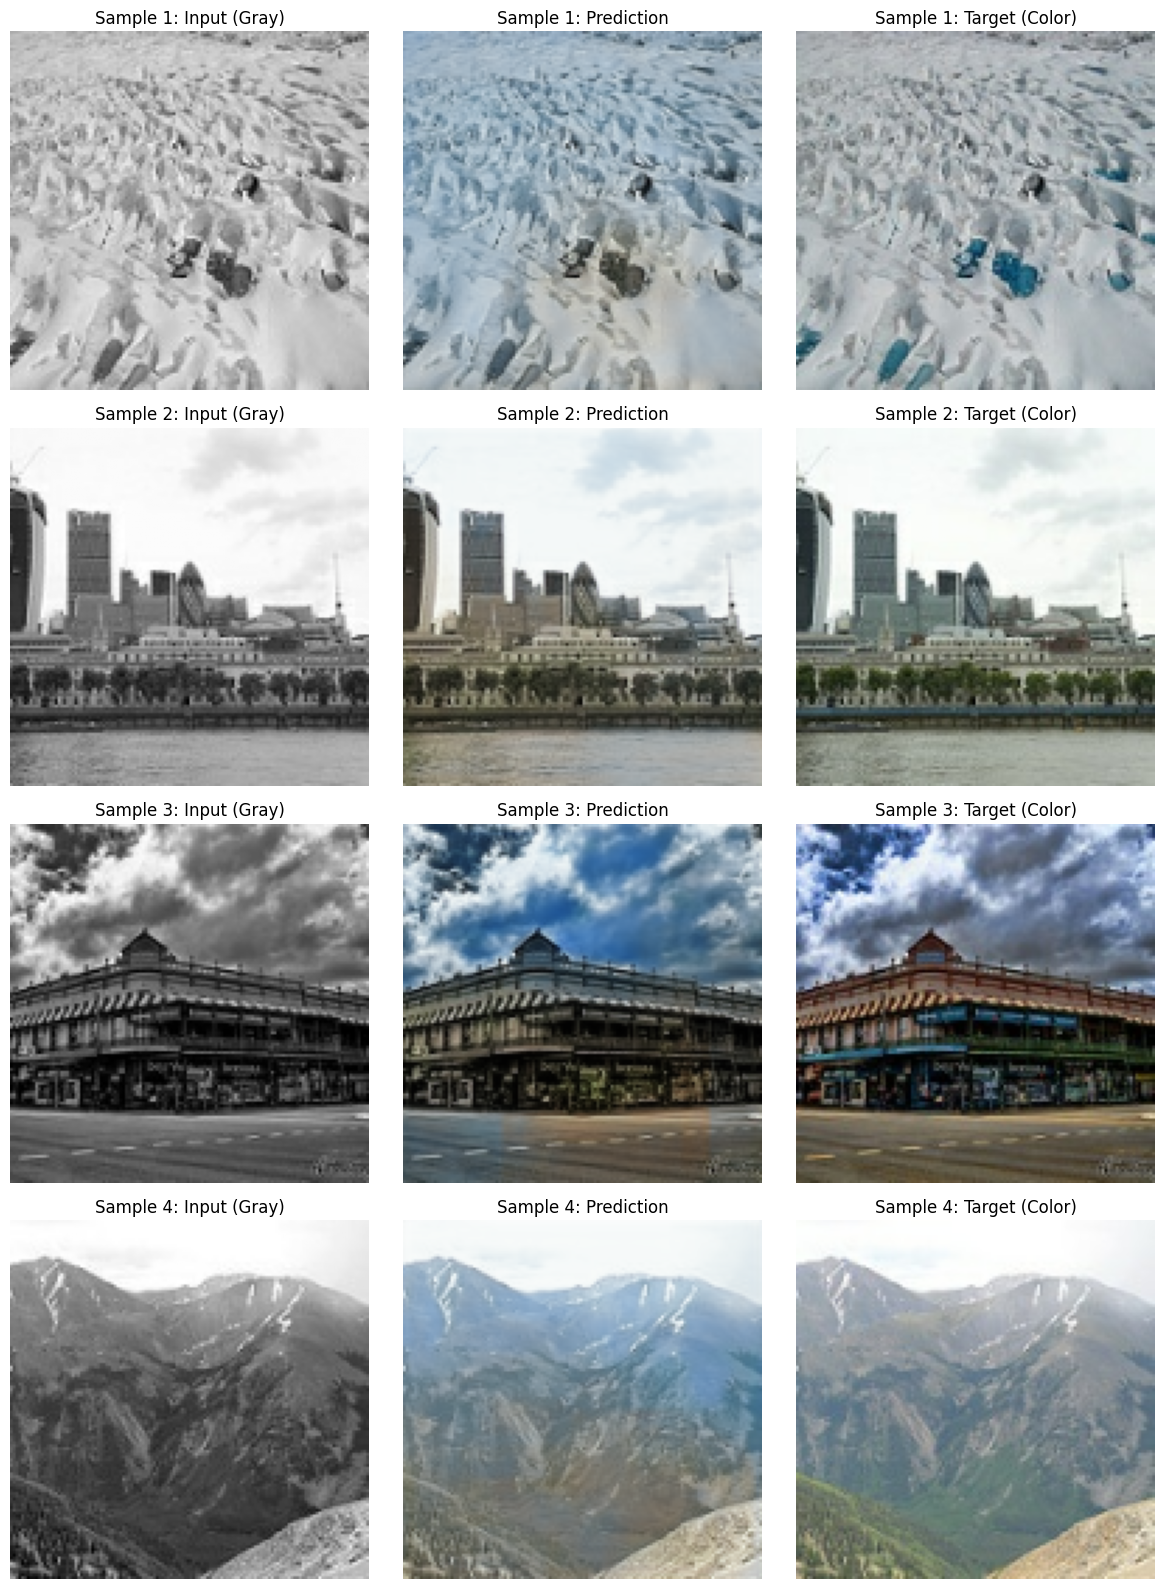

In [24]:
visualize_results(model, val_ds, num_samples=4)